# 01 — Dataset Exploration

This notebook loads a sample of the CNN/DailyMail dataset and inspects article and reference-summary lengths.

**Goal:** understand the summarization data before using a Transformer model.

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\user\Desktop\Text-Summarization\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
dataset = load_dataset(
    "S3IC/cnn_dailymail",
    split="train[:1000]"
)

dataset

c:\Users\user\Desktop\Text-Summarization\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\datasets--S3IC--cnn_dailymail. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 200/200 [00:00<00:00, 2156.16 examples/s]


Dataset({
    features: ['id', 'article', 'highlights'],
    num_rows: 200
})

In [10]:
df = pd.DataFrame(dataset)
df[["article", "highlights"]].head()

,article,highlights
0,(CNN)The Palestinian Authority officially beca...,Membership gives the ICC jurisdiction over all...
1,(CNN)Never mind cats having nine lives. A stra...,"Theia, a bully breed mix, was apparently hit b..."
2,"(CNN)If you've been following the news lately,...",Mohammad Javad Zarif has spent more time with ...
3,(CNN)Five Americans who were monitored for thr...,17 Americans were exposed to the Ebola virus w...
4,(CNN)A Duke student has admitted to hanging a ...,Student is no longer on Duke University campus...


In [11]:
df["article_words"] = df["article"].str.split().str.len()
df["summary_words"] = df["highlights"].str.split().str.len()
df[["article_words", "summary_words"]].describe()

,article_words,summary_words
count,200.000000,200.000000
mean,555.060000,34.735000
std,329.139332,9.974579
min,102.000000,14.000000
25%,282.750000,26.000000
50%,462.500000,33.500000
75%,776.250000,43.000000
max,1497.000000,67.000000


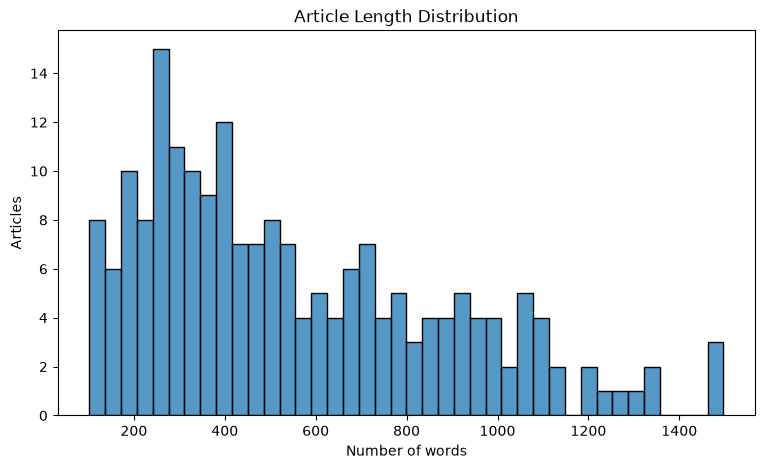

In [12]:
plt.figure(figsize=(9, 5))
sns.histplot(df["article_words"], bins=40)
plt.title("Article Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Articles")
plt.show()

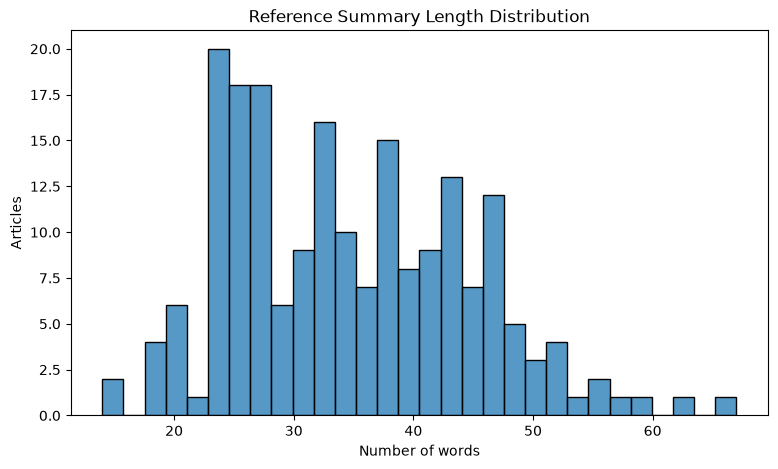

In [13]:
plt.figure(figsize=(9, 5))
sns.histplot(df["summary_words"], bins=30)
plt.title("Reference Summary Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Articles")
plt.show()

In [14]:
sample = df.iloc[0]
print("ARTICLE:")
print(sample["article"][:3000])
print("\nREFERENCE SUMMARY:")
print(sample["highlights"])

ARTICLE:
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. As members of the court, Palestinians may be subject to counter-charges as well. Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki, speaking at Wednesday's cer

## Observations

- News articles are much longer than their reference summaries.
- The summarizer needs to preserve important information while reducing length.
- BART is a sequence-to-sequence Transformer model fine-tuned for this task.